# 1. Setup the Environment

This notebook trains the **final logistic regression baseline** for real-vs-AI image classification.

**Where we stand before this notebook:** earlier experiments identified the strongest logistic-regression settings. The experiment loops have been removed so this notebook trains only the final selected baseline.

**What this notebook does:** it loads the dataset, preprocesses images into flattened pixel vectors, trains one logistic regression model, evaluates it with the same reports used in the other notebooks, and saves the results.


In [1]:
!pip -q install datasets huggingface_hub pillow matplotlib pandas scikit-learn


In [2]:
import os
import random
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from datasets import load_dataset, concatenate_datasets, Features, Image as HFImage, Value
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_recall_fscore_support, precision_score, recall_score, roc_auc_score, roc_curve
from IPython.display import display


# 2. Define Notebook-Wide Settings

**Where we stand:** the packages are available, but the final model settings have not been defined.

**What this section does:** it fixes the random seed and stores the final logistic-regression parameters. The shared decision threshold is `0.35`. Because class `1` means AI-generated, this lower threshold makes the model more conservative about predicting `Real`: an image is called real only when its predicted AI probability is below `0.35`.


In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

FINAL_MODEL_NAME = "final_logistic_regression_64_stronger_reg"
FINAL_IMAGE_SIZE = (64, 64)
FINAL_C = 0.1
FINAL_CLASS_WEIGHT = None
FINAL_THRESHOLD = 0.35

RESULTS_DIR = "results"
MODEL_DIR = "models"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("Final model:", FINAL_MODEL_NAME)
print("Image size:", FINAL_IMAGE_SIZE)
print("C:", FINAL_C)
print("Class weight:", FINAL_CLASS_WEIGHT)
print("Decision threshold:", FINAL_THRESHOLD)


Final model: final_logistic_regression_64_stronger_reg
Image size: (64, 64)
C: 0.1
Class weight: None
Decision threshold: 0.35


# 3. Load and Prepare the Dataset

**Where we stand:** the notebook is configured, but no image data has been loaded yet.

**What this section does:** it loads the main Defactify dataset, adds the extra real-image dataset used in the project, and keeps the same train/validation/test split structure used across the notebooks.


In [4]:
from huggingface_hub import login
login()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:
dataset = load_dataset("Rajarshi-Roy-research/Defactify_Image_Dataset")
extra_dataset = load_dataset("Parveshiiii/AI-vs-Real",verification_mode="no_checks")

print(dataset)
print(extra_dataset)


README.md: 0.00B [00:00, ?B/s]

data/validation-00000-of-00002.parquet:   0%|          | 0.00/333M [00:00<?, ?B/s]

data/validation-00001-of-00002.parquet:   0%|          | 0.00/345M [00:00<?, ?B/s]

data/train-00000-of-00007.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

data/train-00001-of-00007.parquet:   0%|          | 0.00/445M [00:00<?, ?B/s]

...

data/train-00002-of-00005.parquet:   0%|          | 0.00/826M [00:00<?, ?B/s]

data/train-00003-of-00005.parquet:   0%|          | 0.00/805M [00:00<?, ?B/s]

data/train-00004-of-00005.parquet:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9999 [00:00<?, ? examples/s]

DatasetDict({
    validation: Dataset({
        features: ['Caption', 'Image', 'Label_A', 'Label_B'],
        num_rows: 9000
    })
    train: Dataset({
        features: ['Caption', 'Image', 'Label_A', 'Label_B'],
        num_rows: 42000
    })
    test: Dataset({
        features: ['Caption', 'Image', 'Label_A', 'Label_B'],
        num_rows: 45000
    })
})
DatasetDict({
    train: Dataset({
        features: ['image', 'binary_label'],
        num_rows: 13999
    })
})


In [6]:
def prepare_extra_real_images(extra_dataset):
    # Convert the auxiliary real-image dataset to the same schema as the main dataset.
    real_images_only = extra_dataset["train"].filter(lambda x: x["binary_label"] == 1)

    def convert_example(example):
        return {
            "Image": example["image"],
            "Label_A": np.int32(0),
            "Label_B": np.int32(0),
        }

    real_images_converted = real_images_only.map(
        convert_example,
        remove_columns=real_images_only.column_names,
    )

    target_features = Features({
        "Image": HFImage(),
        "Label_A": Value("int32"),
        "Label_B": Value("int32"),
    })

    return real_images_converted.cast(target_features)


extra_real_images = prepare_extra_real_images(extra_dataset)
dataset["train"] = concatenate_datasets([dataset["train"], extra_real_images])

print("New training size after adding extra real images:", len(dataset["train"]))


Filter:   0%|          | 0/13999 [00:00<?, ? examples/s]

Map:   0%|          | 0/10666 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/10666 [00:00<?, ? examples/s]

New training size after adding extra real images: 52666


**Where this leaves us:** the dataset is loaded and the training split contains the additional real images. The next section checks the class balance so the final metrics can be interpreted correctly.


# 4. Inspect Class Balance

**Where we stand:** the dataset is ready, but we need to confirm the binary labels and generator labels.

**What this section does:** it prints the class distribution for `Label_A` and `Label_B` in each split. `Label_A` is used for binary classification, while `Label_B` is used later for per-generator analysis.


In [7]:
LABEL_A_NAMES = {0: "Real", 1: "AI-generated"}
LABEL_B_NAMES = {0: "Real", 1: "SD21", 2: "SDXL", 3: "SD3", 4: "DALLE3", 5: "Midjourney"}


def split_distribution_table(dataset):
    rows = []
    for split_name in ["train", "validation", "test"]:
        split = dataset[split_name]
        for label_id, count in sorted(Counter(split["Label_A"]).items()):
            rows.append({"split": split_name, "label_type": "Label_A", "label_id": label_id, "label_name": LABEL_A_NAMES.get(label_id, str(label_id)), "count": count})
        for label_id, count in sorted(Counter(split["Label_B"]).items()):
            rows.append({"split": split_name, "label_type": "Label_B", "label_id": label_id, "label_name": LABEL_B_NAMES.get(label_id, str(label_id)), "count": count})
    return pd.DataFrame(rows)


distribution_df = split_distribution_table(dataset)
display(distribution_df)


,split,label_type,label_id,label_name,count
0,train,Label_A,0,Real,17666
1,train,Label_A,1,AI-generated,35000
2,train,Label_B,0,Real,17666
3,train,Label_B,1,SD21,7000
4,train,Label_B,2,SDXL,7000
5,train,Label_B,3,SD3,7000
6,train,Label_B,4,DALLE3,7000
7,train,Label_B,5,Midjourney,7000
8,validation,Label_A,0,Real,1500
9,validation,Label_A,1,AI-generated,7500


# 5. Define Logistic Regression Preprocessing

**Where we stand:** the dataset is loaded and checked, but images are still stored as image objects.

**What this section does:** it converts each image to RGB, resizes it to `64 × 64`, scales pixel values to `0–1`, and flattens the image into a one-dimensional feature vector.


In [8]:
def preprocess_image_for_logistic_regression(image, image_size=FINAL_IMAGE_SIZE):
    image = image.convert("RGB")
    image = image.resize(image_size)
    image_array = np.asarray(image, dtype=np.float32) / 255.0
    return image_array.reshape(-1)


def extract_features_and_labels(hf_split, image_size=FINAL_IMAGE_SIZE):
    X = []
    y = []
    for example in hf_split:
        X.append(preprocess_image_for_logistic_regression(example["Image"], image_size=image_size))
        y.append(example["Label_A"])
    return np.vstack(X), np.array(y, dtype=np.int32)


# 6. Build Train and Test Matrices

**Where we stand:** the preprocessing function is defined, but the model still needs matrix inputs.

**What this section does:** it converts the full training split and untouched test split into feature matrices. The scaler is fit only on the training data to avoid test-set leakage.


In [9]:
X_train, y_train = extract_features_and_labels(dataset["train"], image_size=FINAL_IMAGE_SIZE)
X_test, y_test = extract_features_and_labels(dataset["test"], image_size=FINAL_IMAGE_SIZE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training matrix shape:", X_train_scaled.shape)
print("Test matrix shape:", X_test_scaled.shape)


Training matrix shape: (52666, 12288)
Test matrix shape: (45000, 12288)


# 7. Train the Final Logistic Regression Model

**Where we stand:** the data is tabular and scaled.

**What this section does:** it trains one final logistic regression model using the selected parameters. There are no experiment loops.


In [10]:
final_model = LogisticRegression(C=FINAL_C, class_weight=FINAL_CLASS_WEIGHT, max_iter=1000, solver="lbfgs", n_jobs=-1, random_state=SEED)
final_model.fit(X_train_scaled, y_train)
print("Final logistic regression model trained.")


Final logistic regression model trained.


# 8. Evaluate the Final Model

**Where we stand:** the final model has been trained.

**What this section does:** it produces the standardized outputs: classification report, summary statistics with precision and recall, confusion matrices, ROC curve, per-generator AI recall, probability summary, and saved CSV files.


In [11]:
def make_classification_report_df(y_true, y_pred):
    report = classification_report(y_true, y_pred, target_names=["Real", "AI-generated"], output_dict=True, zero_division=0)
    return pd.DataFrame([
        {"Class / Metric": "Real", "Precision": report["Real"]["precision"], "Recall": report["Real"]["recall"], "F1-score": report["Real"]["f1-score"], "Support": int(report["Real"]["support"])},
        {"Class / Metric": "AI-generated", "Precision": report["AI-generated"]["precision"], "Recall": report["AI-generated"]["recall"], "F1-score": report["AI-generated"]["f1-score"], "Support": int(report["AI-generated"]["support"])},
        {"Class / Metric": "Accuracy", "Precision": np.nan, "Recall": np.nan, "F1-score": report["accuracy"], "Support": len(y_true)},
        {"Class / Metric": "Macro average", "Precision": report["macro avg"]["precision"], "Recall": report["macro avg"]["recall"], "F1-score": report["macro avg"]["f1-score"], "Support": int(report["macro avg"]["support"])},
        {"Class / Metric": "Weighted average", "Precision": report["weighted avg"]["precision"], "Recall": report["weighted avg"]["recall"], "F1-score": report["weighted avg"]["f1-score"], "Support": int(report["weighted avg"]["support"])},
    ])


def make_summary_stats_df(model_name, y_true, y_pred, y_prob, threshold):
    p, r, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    return pd.DataFrame([{
        "model_name": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_real": p[0], "recall_real": r[0], "f1_real": f1[0],
        "precision_ai": p[1], "recall_ai": r[1], "f1_ai": f1[1],
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "support_real": int(support[0]),
        "support_ai": int(support[1]),
    }])


def plot_confusion_matrix_df(cm_df, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm_df.values)
    ax.set_xticks(range(len(cm_df.columns)))
    ax.set_yticks(range(len(cm_df.index)))
    ax.set_xticklabels(cm_df.columns)
    ax.set_yticklabels(cm_df.index)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)
    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            value = cm_df.iloc[i, j]
            text = f"{value:.2f}" if isinstance(value, float) else str(value)
            ax.text(j, i, text, ha="center", va="center")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def make_per_generator_df(test_split, y_pred, y_prob):
    label_b = np.array(test_split["Label_B"], dtype=np.int32)
    rows = []
    for label_id in sorted(set(label_b)):
        if label_id == 0:
            continue
        mask = label_b == label_id
        group_preds = y_pred[mask]
        group_probs = y_prob[mask]
        rows.append({
            "AI Generator": LABEL_B_NAMES.get(label_id, f"Label_B {label_id}"),
            "Test Images": int(mask.sum()),
            "Correctly Predicted AI": int((group_preds == 1).sum()),
            "Missed as Real": int((group_preds == 0).sum()),
            "AI Recall": float((group_preds == 1).mean()),
            "Mean Predicted AI Probability": float(group_probs.mean()),
            "Median Predicted AI Probability": float(np.median(group_probs)),
        })
    return pd.DataFrame(rows).sort_values("AI Recall", ascending=False).reset_index(drop=True)


def make_probability_summary_df(y_true, y_prob):
    rows = []
    for label_id, label_name in LABEL_A_NAMES.items():
        mask = y_true == label_id
        rows.append({
            "True Class": label_name,
            "Images": int(mask.sum()),
            "Mean Predicted AI Probability": float(y_prob[mask].mean()),
            "Median Predicted AI Probability": float(np.median(y_prob[mask])),
            "Min Predicted AI Probability": float(y_prob[mask].min()),
            "Max Predicted AI Probability": float(y_prob[mask].max()),
        })
    return pd.DataFrame(rows)


Classification report


,Class / Metric,Precision,Recall,F1-score,Support
0,Real,0.220298,0.144133,0.174256,7500
1,AI-generated,0.839897,0.897973,0.867965,37500
2,Accuracy,NaN,NaN,0.772333,45000
3,Macro average,0.530097,0.521053,0.521111,45000
4,Weighted average,0.736631,0.772333,0.752347,45000


Summary statistics


,model_name,threshold,accuracy,precision_real,recall_real,f1_real,precision_ai,recall_ai,f1_ai,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,roc_auc,support_real,support_ai
0,final_logistic_regression_64_stronger_reg,0.35,0.772333,0.220298,0.144133,0.174256,0.839897,0.897973,0.867965,0.530097,0.521053,0.521111,0.736631,0.772333,0.752347,0.553763,7500,37500


Confusion matrix


,Predicted Real,Predicted AI-generated
Real,1081,6419
AI-generated,3826,33674


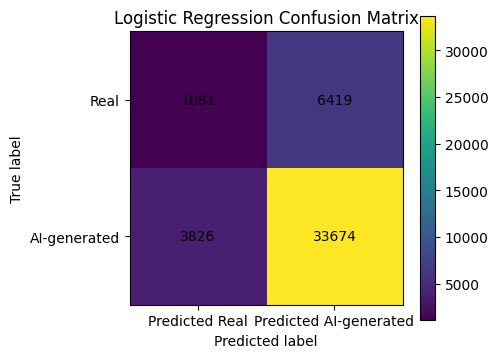

Normalized confusion matrix


,Predicted Real,Predicted AI-generated
Real,0.144133,0.855867
AI-generated,0.102027,0.897973


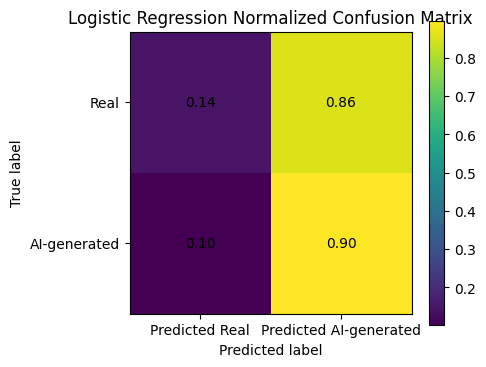

Per-generator AI performance


,AI Generator,Test Images,Correctly Predicted AI,Missed as Real,AI Recall,Mean Predicted AI Probability,Median Predicted AI Probability
0,SDXL,7500,7017,483,0.935600,0.678362,0.707614
1,SD3,7500,6815,685,0.908667,0.721721,0.783937
2,Midjourney,7500,6711,789,0.894800,0.667580,0.702135
3,SD21,7500,6572,928,0.876267,0.666110,0.709531
4,DALLE3,7500,6559,941,0.874533,0.681622,0.734615


Probability summary by true class


,True Class,Images,Mean Predicted AI Probability,Median Predicted AI Probability,Min Predicted AI Probability,Max Predicted AI Probability
0,Real,7500,0.639578,0.676191,0.009340,0.999960
1,AI-generated,37500,0.683079,0.726171,0.000044,0.999994


In [12]:
test_prob_ai = final_model.predict_proba(X_test_scaled)[:, 1]
test_pred = (test_prob_ai >= FINAL_THRESHOLD).astype(int)

classification_report_df = make_classification_report_df(y_test, test_pred)
summary_stats_df = make_summary_stats_df(FINAL_MODEL_NAME, y_test, test_pred, test_prob_ai, FINAL_THRESHOLD)
per_generator_df = make_per_generator_df(dataset["test"], test_pred, test_prob_ai)
probability_summary_df = make_probability_summary_df(y_test, test_prob_ai)

cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
confusion_matrix_df = pd.DataFrame(cm, index=["Real", "AI-generated"], columns=["Predicted Real", "Predicted AI-generated"])
normalized_cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
normalized_confusion_matrix_df = pd.DataFrame(normalized_cm, index=["Real", "AI-generated"], columns=["Predicted Real", "Predicted AI-generated"])

print("Classification report")
display(classification_report_df)
print("Summary statistics")
display(summary_stats_df)
print("Confusion matrix")
display(confusion_matrix_df)
plot_confusion_matrix_df(confusion_matrix_df, "Logistic Regression Confusion Matrix")
print("Normalized confusion matrix")
display(normalized_confusion_matrix_df)
plot_confusion_matrix_df(normalized_confusion_matrix_df, "Logistic Regression Normalized Confusion Matrix")
print("Per-generator AI performance")
display(per_generator_df)
print("Probability summary by true class")
display(probability_summary_df)


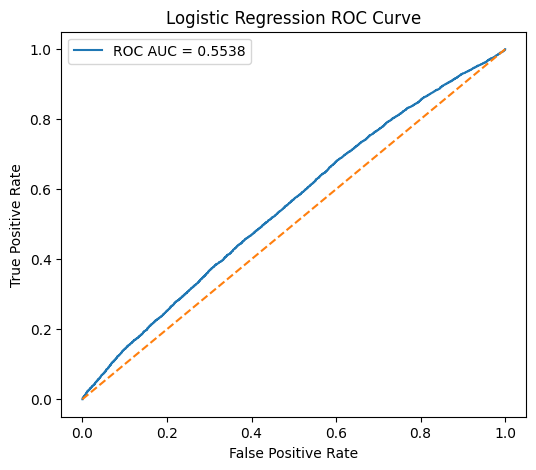

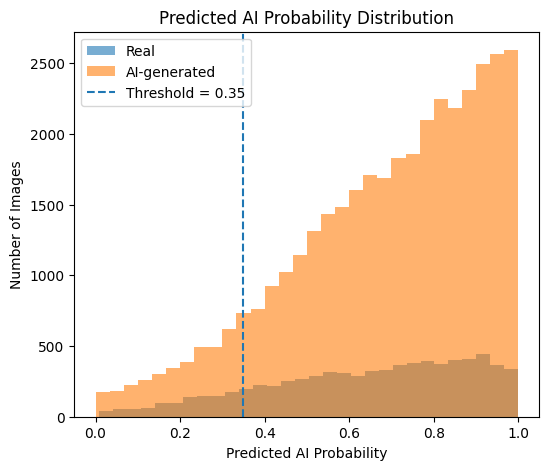

In [13]:
fpr, tpr, roc_thresholds = roc_curve(y_test, test_prob_ai)
roc_auc = roc_auc_score(y_test, test_prob_ai)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()

plt.figure(figsize=(6, 5))
plt.hist(test_prob_ai[y_test == 0], bins=30, alpha=0.6, label="Real")
plt.hist(test_prob_ai[y_test == 1], bins=30, alpha=0.6, label="AI-generated")
plt.axvline(FINAL_THRESHOLD, linestyle="--", label=f"Threshold = {FINAL_THRESHOLD}")
plt.xlabel("Predicted AI Probability")
plt.ylabel("Number of Images")
plt.title("Predicted AI Probability Distribution")
plt.legend()
plt.show()


# 9. Save Model and Results

**Where we stand:** the final model has been trained and evaluated.

**What this section does:** it saves the model package and all standardized result tables so they can be reused in the paper or combined with outputs from the other notebooks.


In [14]:
predictions_df = pd.DataFrame({
    "true_label": y_test,
    "true_label_name": [LABEL_A_NAMES[int(x)] for x in y_test],
    "predicted_label": test_pred,
    "predicted_label_name": [LABEL_A_NAMES[int(x)] for x in test_pred],
    "predicted_ai_probability": test_prob_ai,
    "threshold": FINAL_THRESHOLD,
    "label_b": np.array(dataset["test"]["Label_B"], dtype=np.int32),
    "label_b_name": [LABEL_B_NAMES[int(x)] for x in dataset["test"]["Label_B"]],
})

classification_report_df.to_csv(os.path.join(RESULTS_DIR, f"{FINAL_MODEL_NAME}_classification_report.csv"), index=False)
summary_stats_df.to_csv(os.path.join(RESULTS_DIR, f"{FINAL_MODEL_NAME}_summary_stats.csv"), index=False)
per_generator_df.to_csv(os.path.join(RESULTS_DIR, f"{FINAL_MODEL_NAME}_per_generator_results.csv"), index=False)
probability_summary_df.to_csv(os.path.join(RESULTS_DIR, f"{FINAL_MODEL_NAME}_probability_summary.csv"), index=False)
confusion_matrix_df.to_csv(os.path.join(RESULTS_DIR, f"{FINAL_MODEL_NAME}_confusion_matrix.csv"))
normalized_confusion_matrix_df.to_csv(os.path.join(RESULTS_DIR, f"{FINAL_MODEL_NAME}_normalized_confusion_matrix.csv"))
predictions_df.to_csv(os.path.join(RESULTS_DIR, f"{FINAL_MODEL_NAME}_test_predictions.csv"), index=False)

model_package = {"model": final_model, "scaler": scaler, "image_size": FINAL_IMAGE_SIZE, "threshold": FINAL_THRESHOLD, "C": FINAL_C, "class_weight": FINAL_CLASS_WEIGHT, "label_a_names": LABEL_A_NAMES, "label_b_names": LABEL_B_NAMES}
joblib.dump(model_package, os.path.join(MODEL_DIR, f"{FINAL_MODEL_NAME}.joblib"))

print("Saved standardized result files to:", RESULTS_DIR)
print("Saved model package to:", os.path.join(MODEL_DIR, f"{FINAL_MODEL_NAME}.joblib"))


Saved standardized result files to: results
Saved model package to: models/final_logistic_regression_64_stronger_reg.joblib


# 10. Final Interpretation

Use this section for the paper-ready interpretation after the notebook has run.

- **Overall performance:** summarize accuracy, macro F1, and ROC AUC.
- **Real-photo performance:** focus on real precision and real recall because real images are the minority class.
- **AI-generated performance:** summarize AI precision and recall overall and by generator.
- **Main limitation:** logistic regression uses flattened pixels, so it does not preserve spatial relationships between pixels.
